US-02 Build a Custom Keras Model
To set your product apart from others using VADER, you can enhance it by developing tailor-made sentiment analysis models for your clients. It is important for your application to demonstrate that it can accomodate custom sentiment analysis models. In this step, you will construct a personalized sentiment analysis model using Keras.

You will use the UCI Labelled Sentences dataset for this step. The dataset consists of a collection of sentences that have been labeled with their respective sentiment or category. Each sentence in the dataset is labeled with a specific category or sentiment.

Create a new Colab notebook and proceed with the steps described below:

Tip: Feel free to experiment with the code snippets provided below to see how the accuracy of the model is affected.

1. Download the dataset and unzip it in Google Colab
Use the following commands to download and unzip the UCI Labelled Sentences dataset in your Colab notebook:

In [ ]:
!pip install keras==3.11.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.5 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-hub 0.26.0 requires keras>=3.13, but you have keras 3.11.3 which is incompatible.


In [ ]:
# download dataset from the UCI website
!curl -o uci-labelled-sentences.zip https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip

# unzip dataset in Colab
!unzip uci-labelled-sentences.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84188    0 84188    0     0   673k      0 --:--:-- --:--:-- --:--:--  673k
Archive:  uci-labelled-sentences.zip
replace sentiment labelled sentences/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sentiment labelled sentences/.DS_Store  
replace __MACOSX/sentiment labelled sentences/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/sentiment labelled sentences/._.DS_Store  
replace sentiment labelled sentences/amazon_cells_labelled.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sentiment labelled sentences/amazon_cells_labelled.txt  
replace sentiment labelled sentences/imdb_labelled.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sentiment labelled sentences/imdb_labelled.txt  
replace __MACOSX/sentiment labelled sentences/._imdb_labelled.txt? [y]es, [n]o, [A]ll, [

2. Import Keras and other libraries
Import the necessary libraries for data manipulation and deep-learning modeling. Include the following code in your notebook:

In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM
from keras.callbacks import EarlyStopping

3. Load the datasets
The datasets include data from Yelp, Amazon, and IMDB, each with labeled sentences. Load the datasets using the following code:

In [ ]:
df_list = []

# Yelp
df_yelp = pd.read_csv('sentiment labelled sentences/yelp_labelled.txt', names=['sentence', 'label'], sep='\t')
df_yelp['source'] = 'yelp'
df_list.append(df_yelp)

# Amazon
df_amazon = pd.read_csv('sentiment labelled sentences/amazon_cells_labelled.txt', names=['sentence', 'label'], sep='\t')
df_amazon['source'] = 'amazon'
df_list.append(df_amazon)

# IMDB
df_imdb = pd.read_csv('sentiment labelled sentences/imdb_labelled.txt', names=['sentence', 'label'], sep='\t')
df_imdb['source'] = 'imdb'
df_list.append(df_imdb)

# Concatenate the dataframes
df = pd.concat(df_list)

df.head()

,sentence,label,source
0,Wow... Loved this place.,1,yelp
1,Crust is not good.,0,yelp
2,Not tasty and the texture was just nasty.,0,yelp
3,Stopped by during the late May bank holiday of...,1,yelp
4,The selection on the menu was great and so wer...,1,yelp


Note: The code above creates a list called df_list to store multiple pandas dataframes. Each dataframe corresponds to a dataset from sources like Yelp, Amazon, and IMDB. The code reads the CSV files of these datasets and assigns column names ('sentence' and 'label') to the dataframe. It also adds a new column, 'source', to each dataframe to indicate the source of the data. Finally, the code concatenates all the dataframes in df_list into a single dataframe called df. This allows for a combined dataset from multiple sources.

4. Tokenize
Tokenize the sentences by converting them into sequences of numbers using the Tokenizer class. Include the code segment below:

In [ ]:
max_features = 2000
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(df['sentence'].values)
X = tokenizer.texts_to_sequences(df['sentence'].values)
X = pad_sequences(X)
y = df['label'].values

5. Split the dataset
Split the dataset into training and test sets using the train_test_split function from sklearn.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12)

6. Define the model
Create the sentiment analysis model using Keras. The model includes an embedding layer, LSTM layer, and dense layer. Here's an example of how to define the model:

In [ ]:
def create_model():
  model = Sequential()
  model.add(Embedding(max_features, 64, input_length=X.shape[1]))
  model.add(LSTM(16))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

model = create_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


7. Train the model
Train the model using the training set and evaluate its performance on the test set. Include the code below:

In [ ]:
model.fit(X_train, y_train, epochs=6, batch_size=16, validation_data=(X_test, y_test), callbacks = [EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=2, verbose=1)])

Epoch 1/6
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 426ms/step - accuracy: 0.6369 - loss: 0.6431 - val_accuracy: 0.8000 - val_loss: 0.4940
Epoch 2/6
152/152 ━━━━━━━━━━━━━━━━━━━━ 83s 435ms/step - accuracy: 0.8486 - loss: 0.3669 - val_accuracy: 0.8091 - val_loss: 0.3846
Epoch 3/6
152/152 ━━━━━━━━━━━━━━━━━━━━ 65s 427ms/step - accuracy: 0.9260 - loss: 0.2138 - val_accuracy: 0.8091 - val_loss: 0.4134
Epoch 4/6
152/152 ━━━━━━━━━━━━━━━━━━━━ 65s 427ms/step - accuracy: 0.9570 - loss: 0.1404 - val_accuracy: 0.8212 - val_loss: 0.4259
Epoch 5/6
152/152 ━━━━━━━━━━━━━━━━━━━━ 83s 434ms/step - accuracy: 0.9719 - loss: 0.0942 - val_accuracy: 0.8061 - val_loss: 0.4829
Epoch 6/6
152/152 ━━━━━━━━━━━━━━━━━━━━ 81s 425ms/step - accuracy: 0.9855 - loss: 0.0629 - val_accuracy: 0.8152 - val_loss: 0.5350
Epoch 6: early stopping


8. Save the model and the tokenizer
Use the code below to save the trained model and tokenizer for future use.

In [ ]:
model.save("uci_sentimentanalysis.h5")

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.DEFAULT_PROTOCOL)

In [ ]:
model.save('my_sentimentanalysis.keras')

9. Download the model and tokenizer to your computer
The tokenizer and the trained model are ready to be used in your app. Download the files to your computer.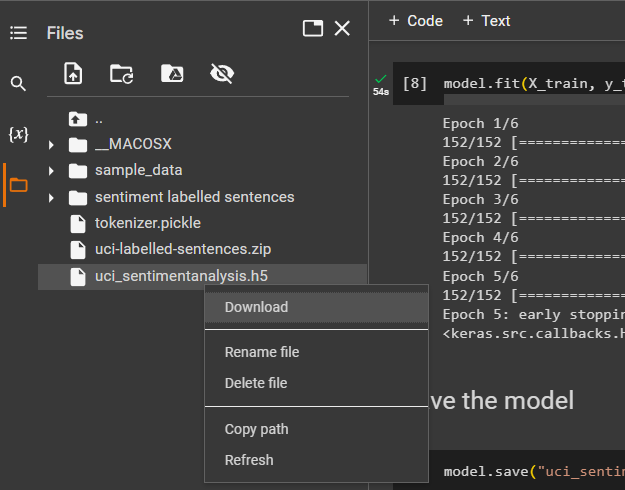